In [14]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1 import make_axes_locatable
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.plot import reshape_as_image
import contextily as ctx
from pyproj import Transformer

PROJ_CRS   = "EPSG:32717"   # UTM Zone 17S
NBR_TIF_LL = r"C:\Soilgrids\Llaviuco\NBR\dNBR_llaviuco.tif"
NBR_TIF_YA = r"C:\Soilgrids\Yanasacha\dNBR_yanasacha.tif"
FIRE_SHP_LL = r"C:\Soilgrids\Llaviuco\NBR\Llaviuco.shp"
FIRE_SHP_YA = r"C:\Soilgrids\Yanasacha\Yanasacha.shp"
SITES_LL    = r"C:\Soilgrids\datos_martha\sites_Llaviuco_clean.csv"
SITES_YA    = r"C:\Soilgrids\datos_martha\sites_Yansascha_clean.csv"


In [15]:
# ── dNBR colour scale (USGS burn-severity classes) ───────────────────────────
# Boundaries in dNBR units (reflectance ×1000 or raw — auto-detected from data range)
DNBR_BOUNDS = [-500, -251, -101,  99, 269, 439, 659, 1300]
DNBR_COLORS = ["#7FBF7B", "#C8E6C9", "#FFFFCC", "#FFF176",
               "#FFB300", "#E64A19", "#7B1FA2"]
DNBR_LABELS = [
    "Enhanced regrowth (high) < -0.25",
    "Enhanced regrowth (low)  -0.25 – -0.10",
    "Unburned                 -0.10 – 0.10",
    "Low severity              0.10 – 0.27",
    "Moderate-low severity     0.27 – 0.44",
    "Moderate-high severity    0.44 – 0.66",
    "High severity            > 0.66",
]
dnbr_cmap = mcolors.ListedColormap(DNBR_COLORS)
dnbr_norm = mcolors.BoundaryNorm(DNBR_BOUNDS, dnbr_cmap.N)

# ── Helper: CSV sites → GeoDataFrame ─────────────────────────────────────────
def csv_to_gdf(path):
    df = pd.read_csv(path)
    return gpd.GeoDataFrame(
        df, geometry=gpd.points_from_xy(df["Lon"], df["Lat"]), crs="EPSG:4326"
    ).to_crs(PROJ_CRS)

ll_sites = csv_to_gdf(SITES_LL)
ya_sites = csv_to_gdf(SITES_YA)

# Classify Llaviuco: LR → Reference, rest → Burn site
ll_sites["group"] = ll_sites["Reference"].apply(
    lambda r: "Reference" if str(r).startswith("LR") else "Burn site"
)

# Classify Yanasacha: YL → Low burn, YH → High burn, else Reference
def ya_group(r):
    r = str(r)
    if r.startswith("YL"):   return "Low burn"
    if r.startswith("YH"):   return "High burn"
    return "Reference"

ya_sites["group"] = ya_sites["Reference"].apply(ya_group)

ll_palette = {
    "Reference": {"color": "#2196F3", "marker": "o"},
    "Burn site":  {"color": "#F44336", "marker": "^"},
}
ya_palette = {
    "Reference": {"color": "#2196F3", "marker": "o"},
    "Low burn":  {"color": "#FF9800", "marker": "^"},
    "High burn": {"color": "#D32F2F", "marker": "s"},
}


In [16]:
# ── Load rasters + fire polygons ─────────────────────────────────────────────
def load_nbr(tif_path, fire_shp):
    """Return (data_array, extent_in_PROJ_CRS, fire_GeoDataFrame)."""
    with rasterio.open(tif_path) as src:
        data = src.read(1).astype(float)
        # Mask nodata
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
        # Reproject raster bounds to PROJ_CRS for plotting
        from rasterio.warp import transform_bounds
        left, bottom, right, top = transform_bounds(
            src.crs, PROJ_CRS, src.bounds.left, src.bounds.bottom,
            src.bounds.right, src.bounds.top
        )
        extent = [left, right, bottom, top]   # (for imshow: [left,right,bottom,top])
    fire = gpd.read_file(fire_shp).to_crs(PROJ_CRS)
    return data, extent, fire

ll_data, ll_extent, ll_fire = load_nbr(NBR_TIF_LL, FIRE_SHP_LL)
ya_data, ya_extent, ya_fire = load_nbr(NBR_TIF_YA, FIRE_SHP_YA)

# Auto-detect scale: raw dNBR is usually -2000…+2000; normalised is -1…+1
# Rescale to ×1000 if values are in (-2, 2) range
for name, arr in [("Llaviuco", ll_data), ("Yanasacha", ya_data)]:
    valid = arr[~np.isnan(arr)]
    print(f"{name}: min={valid.min():.3f}  max={valid.max():.3f}  "
          f"mean={valid.mean():.3f}  nodata fraction={np.isnan(arr).mean():.2%}")


Llaviuco: min=-1037.037  max=883.126  mean=76.732  nodata fraction=0.00%
Yanasacha: min=-1112.357  max=1027.108  mean=97.398  nodata fraction=0.00%


In [17]:
# ── Map drawing helper ────────────────────────────────────────────────────────
PAD_FRAC   = 0.12
MARKER_SIZE = 55

def add_latlon_ticks(ax, minx, miny, maxx, maxy):
    t = Transformer.from_crs(PROJ_CRS, "EPSG:4326", always_xy=True)
    xt = ax.get_xticks()
    yt = ax.get_yticks()
    lons, _ = t.transform(xt, np.full_like(xt, (miny + maxy) / 2))
    _, lats = t.transform(np.full_like(yt, (minx + maxx) / 2), yt)
    ax.set_xticklabels([f"{v:.3f}°" for v in lons], fontsize=7)
    ax.set_yticklabels([f"{v:.3f}°" for v in lats], fontsize=7)

def draw_nbr_panel(ax, nbr_data, nbr_extent, fire_gdf, sites_gdf, palette, title,
                   scale=1.0, show_sites=False):
    """
    nbr_extent: [left, right, bottom, top] in PROJ_CRS metres.
    scale: multiply raster values (use 1000 if data is in -1…1 range).
    show_sites: if False, sample-site markers and their legend entries are omitted.
    """
    data_scaled = nbr_data * scale

    # Padded view extent from fire polygon (+ sites when shown)
    bounds_list = [fire_gdf.total_bounds]
    if show_sites and sites_gdf is not None and not sites_gdf.empty:
        bounds_list.append(sites_gdf.total_bounds)
    all_minx = min(b[0] for b in bounds_list)
    all_miny = min(b[1] for b in bounds_list)
    all_maxx = max(b[2] for b in bounds_list)
    all_maxy = max(b[3] for b in bounds_list)
    dx = (all_maxx - all_minx) * PAD_FRAC
    dy = (all_maxy - all_miny) * PAD_FRAC
    vminx, vminy = all_minx - dx, all_miny - dy
    vmaxx, vmaxy = all_maxx + dx, all_maxy + dy

    ax.set_xlim(vminx, vmaxx)
    ax.set_ylim(vminy, vmaxy)
    ax.set_autoscale_on(False)

    # Basemap
    ctx.add_basemap(ax, crs=PROJ_CRS, source=ctx.providers.Esri.WorldTopoMap,
                    zoom="auto", attribution=False)
    ax.text(0.5, 0.01, "© Esri — World Topo Map",
            transform=ax.transAxes, fontsize=6, color="gray",
            ha="center", va="bottom", zorder=10)

    # dNBR raster
    im = ax.imshow(
        data_scaled,
        extent=nbr_extent,          # [left, right, bottom, top] in metres
        origin="upper",
        cmap=dnbr_cmap,
        norm=dnbr_norm,
        alpha=0.75,
        zorder=3,
    )

    # Fire polygon outline
    fire_gdf.boundary.plot(ax=ax, color="#B71C1C", linewidth=1.5, zorder=4,
                           label="Burned-area boundary")

    # Sample sites (optional)
    if show_sites and sites_gdf is not None:
        for group, style in palette.items():
            sub = sites_gdf[sites_gdf["group"] == group]
            if sub.empty:
                continue
            ax.scatter(sub.geometry.x, sub.geometry.y,
                       c=style["color"], marker=style["marker"],
                       s=MARKER_SIZE, edgecolors="black", linewidths=0.5,
                       zorder=6, label=group)

    # Re-apply limits (imshow can expand them)
    ax.set_xlim(vminx, vmaxx)
    ax.set_ylim(vminy, vmaxy)

    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)
    cbar = plt.colorbar(im, cax=cax, ticks=DNBR_BOUNDS)
    cbar.ax.set_yticklabels(
        [str(b) for b in DNBR_BOUNDS], fontsize=6
    )
    cbar.set_label("dNBR (×1000)", fontsize=8)

    # Legend
    handles = [mpatches.Patch(facecolor="#B71C1C", alpha=0.7,
                               label="Burned-area boundary")]
    if show_sites:
        for group, style in palette.items():
            handles.append(Line2D([0], [0], marker=style["marker"], color="w",
                                   markerfacecolor=style["color"],
                                   markeredgecolor="black", markeredgewidth=0.5,
                                   markersize=8, label=group))
    ax.legend(handles=handles, loc="upper left", fontsize=8, framealpha=0.9)

    # North arrow
    ax.annotate("N", xy=(0.96, 0.13), xycoords="axes fraction",
                fontsize=11, fontweight="bold", ha="center", va="bottom")
    ax.annotate("", xy=(0.96, 0.13), xytext=(0.96, 0.08),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", lw=1.2, color="black"))

    # Scale bar
    ax.add_artist(ScaleBar(1, units="m", location="lower right",
                           length_fraction=0.20, box_alpha=0.7,
                           font_properties={"size": 8}))

    # Tick labels → lat/lon
    add_latlon_ticks(ax, vminx, vminy, vmaxx, vmaxy)
    ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.5, color="gray")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel("Longitude", fontsize=9)
    ax.set_ylabel("Latitude", fontsize=9)


# ── Detect scale factor ───────────────────────────────────────────────────────
def detect_scale(arr):
    """Return 1000 if values are normalised (-1…1), else 1."""
    valid = arr[~np.isnan(arr)]
    return 1000 if valid.max() <= 2.0 and valid.min() >= -2.0 else 1

ll_scale = detect_scale(ll_data)
ya_scale = detect_scale(ya_data)
print(f"Llaviuco scale factor: {ll_scale}, Yanasacha scale factor: {ya_scale}")


Llaviuco scale factor: 1, Yanasacha scale factor: 1


C:\Users\UDA\AppData\Local\Temp\ipykernel_24012\4128846450.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{v:.3f}°" for v in lons], fontsize=7)
C:\Users\UDA\AppData\Local\Temp\ipykernel_24012\4128846450.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{v:.3f}°" for v in lats], fontsize=7)
C:\Users\UDA\AppData\Local\Temp\ipykernel_24012\4128846450.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{v:.3f}°" for v in lons], fontsize=7)
C:\Users\UDA\AppData\Local\Temp\ipykernel_24012\4128846450.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{v:.3f}°" for 

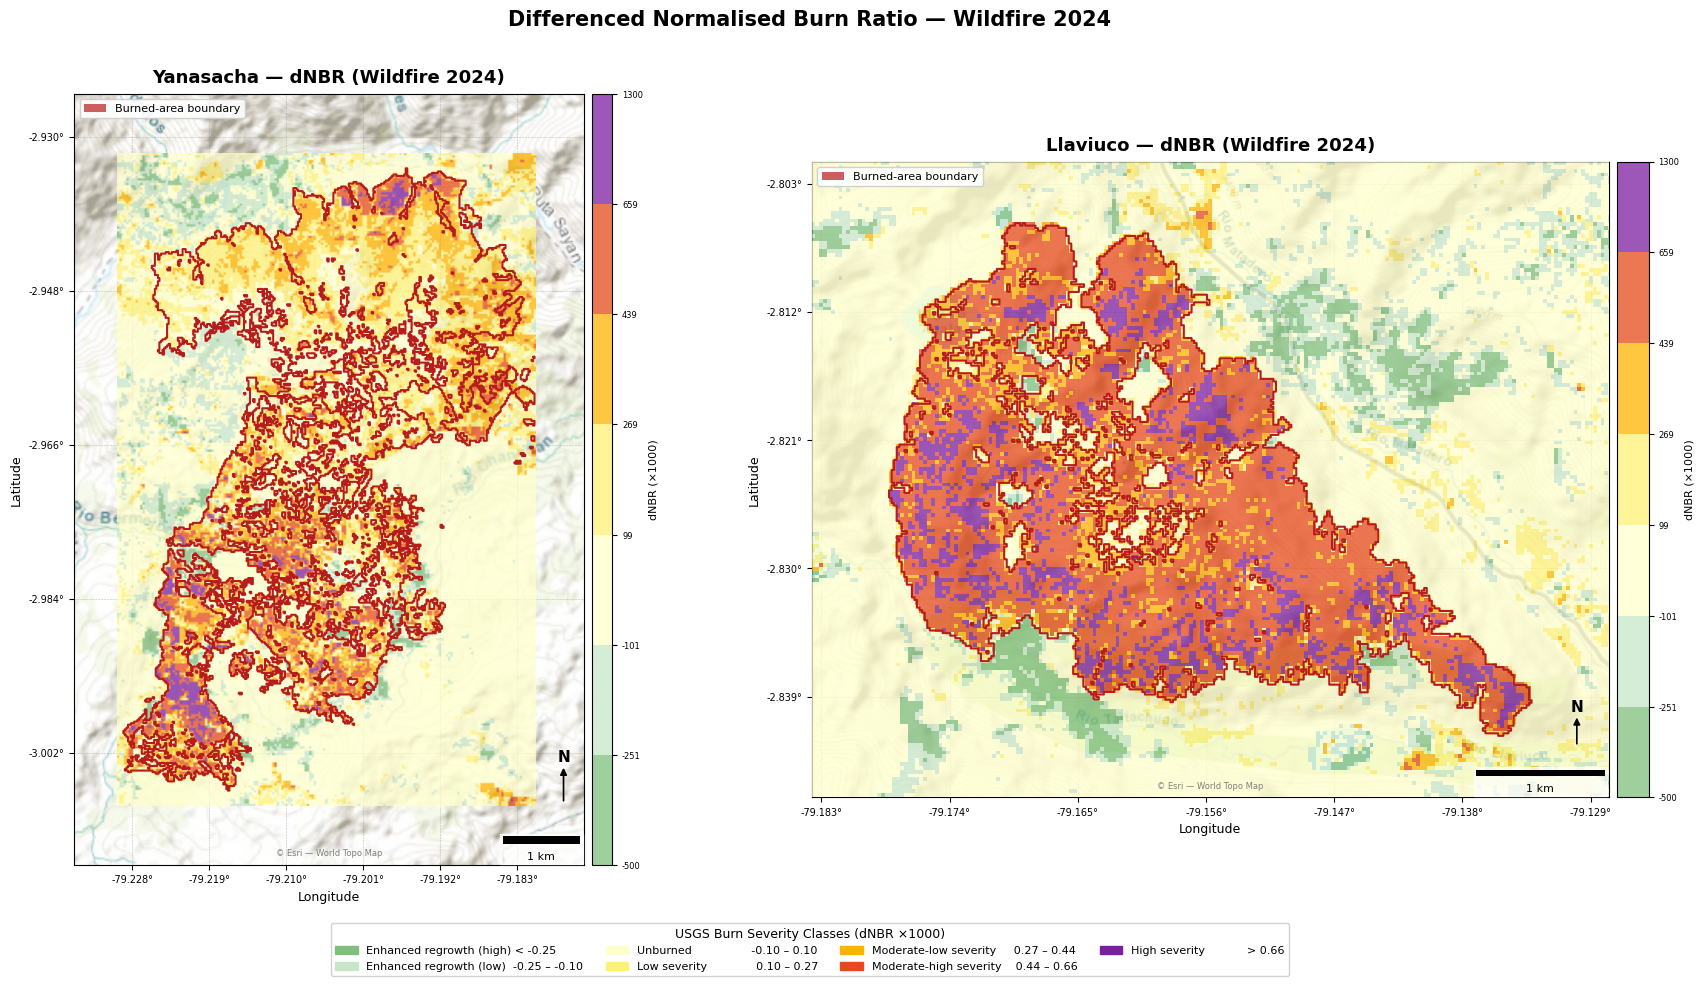

Saved → C:\Soilgrids\maps\nbr_yanasacha_llaviuco.png


In [18]:
# ── Plot: side-by-side dNBR maps ──────────────────────────────────────────────
import os
os.makedirs(r"C:\Soilgrids\maps", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

draw_nbr_panel(
    axes[0], ya_data, ya_extent, ya_fire, ya_sites, ya_palette,
    title="Yanasacha — dNBR (Wildfire 2024)", scale=ya_scale,
)
draw_nbr_panel(
    axes[1], ll_data, ll_extent, ll_fire, ll_sites, ll_palette,
    title="Llaviuco — dNBR (Wildfire 2024)", scale=ll_scale,
)

plt.suptitle("Differenced Normalised Burn Ratio — Wildfire 2024",
             fontsize=15, fontweight="bold", y=1.01)

# Shared USGS severity legend below the maps
legend_patches = [
    mpatches.Patch(color=c, label=l)
    for c, l in zip(DNBR_COLORS, DNBR_LABELS)
]
fig.legend(handles=legend_patches, loc="lower center", ncol=4,
           fontsize=8, framealpha=0.9,
           title="USGS Burn Severity Classes (dNBR ×1000)",
           title_fontsize=9,
           bbox_to_anchor=(0.5, -0.07))

plt.tight_layout()
out_path = r"C:\Soilgrids\maps\nbr_yanasacha_llaviuco.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")


C:\Users\UDA\AppData\Local\Temp\ipykernel_24012\4128846450.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{v:.3f}°" for v in lons], fontsize=7)
C:\Users\UDA\AppData\Local\Temp\ipykernel_24012\4128846450.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{v:.3f}°" for v in lats], fontsize=7)
C:\Users\UDA\AppData\Local\Temp\ipykernel_24012\4128846450.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{v:.3f}°" for v in lons], fontsize=7)
C:\Users\UDA\AppData\Local\Temp\ipykernel_24012\4128846450.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f"{v:.3f}°" for 

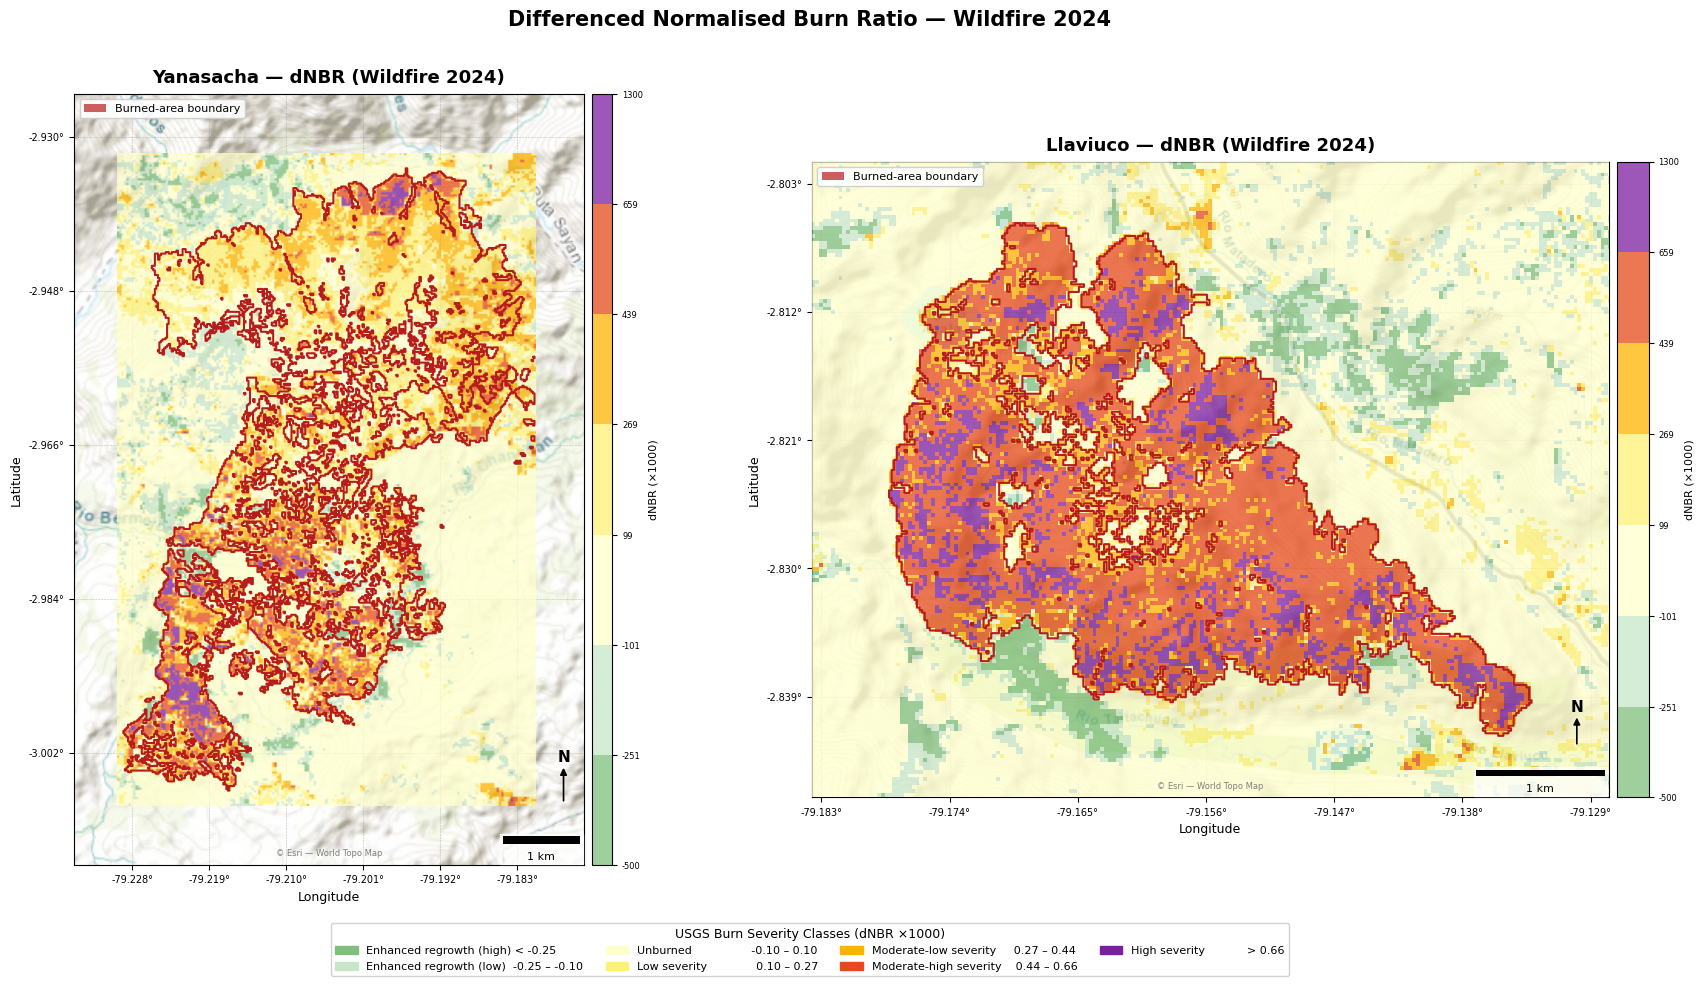

Saved → C:\Soilgrids\maps\nbr_yanasacha_llaviuco_nosites.png


In [19]:
# ── Plot: dNBR only (no sample sites) — for thesis intro ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

draw_nbr_panel(
    axes[0], ya_data, ya_extent, ya_fire, ya_sites, ya_palette,
    title="Yanasacha — dNBR (Wildfire 2024)", scale=ya_scale,
    show_sites=False,
)
draw_nbr_panel(
    axes[1], ll_data, ll_extent, ll_fire, ll_sites, ll_palette,
    title="Llaviuco — dNBR (Wildfire 2024)", scale=ll_scale,
    show_sites=False,
)

plt.suptitle("Differenced Normalised Burn Ratio — Wildfire 2024",
             fontsize=15, fontweight="bold", y=1.01)

# Shared USGS severity legend below the maps
legend_patches = [
    mpatches.Patch(color=c, label=l)
    for c, l in zip(DNBR_COLORS, DNBR_LABELS)
]
fig.legend(handles=legend_patches, loc="lower center", ncol=4,
           fontsize=8, framealpha=0.9,
           title="USGS Burn Severity Classes (dNBR ×1000)",
           title_fontsize=9,
           bbox_to_anchor=(0.5, -0.07))

plt.tight_layout()
out_path = r"C:\Soilgrids\maps\nbr_yanasacha_llaviuco_nosites.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")
